# Image Processing and Machine Vision

#### Assignment 02 - Fitting and Allignment

### Question 1 - Blob Detection

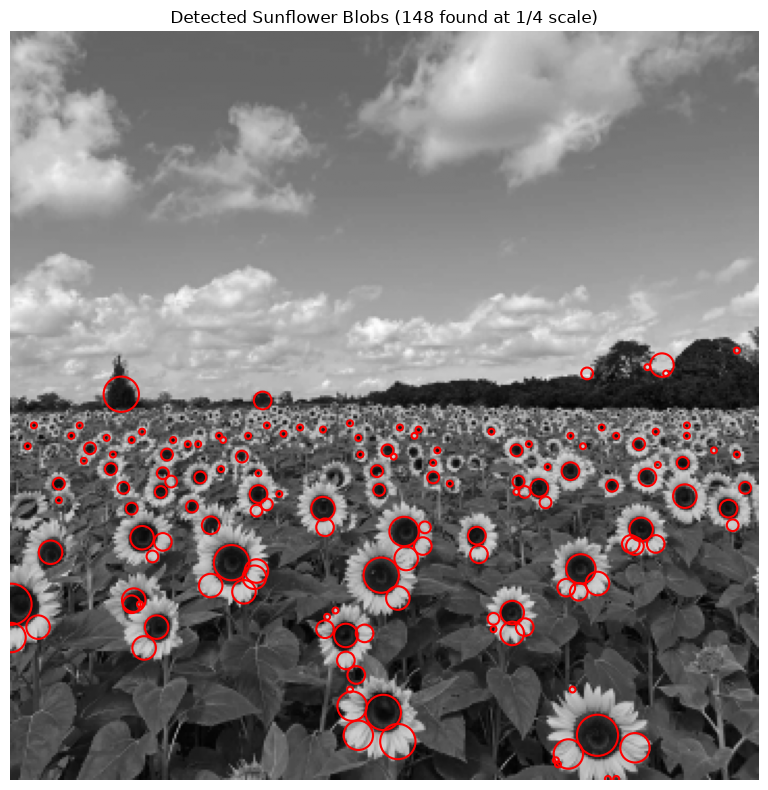

In [47]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter

im =cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
im= cv.cvtColor(im, cv.COLOR_BGR2GRAY) #Converting to Gray Scale image

sigmas= np.linspace(1,10,10) #Sigma Values
h,w=im.shape #Height and Width of the image

im1= im.astype(np.float32)/255 #Scalinng the image 
scale_space = np.empty((h, w, len(sigmas)), dtype=np.float32)

for i, sigma in enumerate(sigmas):
    log_hw = int(np.ceil(3 * sigma))
    X, Y = np.meshgrid(np.arange(-log_hw, log_hw + 1), np.arange(-log_hw, log_hw + 1)) 
    # NLoG Filter
    r_sq = X**2 + Y**2
    LoG = (1.0 / (np.pi * sigma**2)) * ((r_sq / (2 * sigma**2)) - 1) * np.exp(-r_sq / (2 * sigma**2))
    scale_space[:, :, i] = np.abs(cv.filter2D(im1, -1, LoG))


threshold = 0.25  # We need to adjest the threshold 
local_max = maximum_filter(scale_space, size=(3, 3, 3)) == scale_space
detected_mask = local_max & (scale_space > threshold)

y_coords, x_coords, scale_indices = np.where(detected_mask)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(im,cmap='gray')

for y, x, s_idx in zip(y_coords, x_coords, scale_indices):
    sigma = sigmas[s_idx]
    radius = np.sqrt(2) * sigma
    circle = plt.Circle((x, y), radius, color='red', linewidth=1.5, fill=False)
    ax.add_patch(circle)

ax.set_axis_off()
plt.title(f'Detected Sunflower Blobs ({len(y_coords)} found at 1/4 scale)')
plt.tight_layout()
plt.show()

In [48]:
radii = np.sqrt(2) * sigmas[scale_indices]
max_idx = np.argmax(radii)

max_y, max_x, max_s = y_coords[max_idx], x_coords[max_idx], scale_indices[max_idx]
max_response = scale_space[max_y, max_x, max_s]

print(f"Largest blob: radius={radii[max_idx]:.2f}, sigma={sigmas[max_s]:.2f}, " 
      f"location=(x={max_x}, y={max_y}), response={max_response:.4f}")

Largest blob: radius=9.90, sigma=7.00, location=(x=0, y=275), response=0.3291


### Question 2 - RANSAC

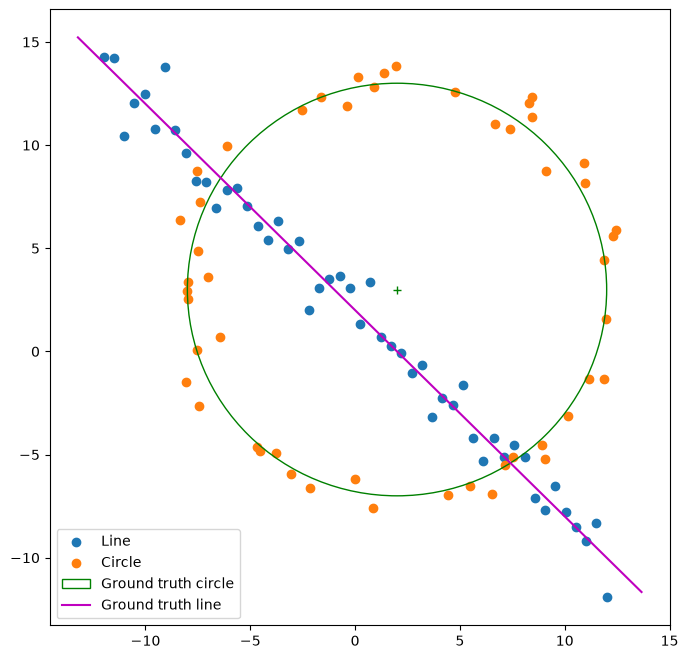

In [49]:
# Generation of a Noisy Point Set Conforming to a Line and a Circle
import numpy as np
from scipy.optimize import minimize
from scipy import linalg
import matplotlib.pyplot as plt
# import tikzplotlib  # unused here; uncomment only if you export the figure to TikZ

# np.random.seed(0)
N = 100
half_n = N // 2

# Circle
r = 10
x0_gt, y0_gt = 2, 3  # Center
s = r / 16
t = np.random.uniform(0, 2 * np.pi, half_n)
n = s * np.random.randn(half_n)
x, y = x0_gt + (r + n) * np.cos(t), y0_gt + (r + n) * np.sin(t)
X_circ = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

# Line
s = 1.
m, b = -1, 2
x = np.linspace(-12, 12, half_n)
y = m * x + b + s * np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

X = np.vstack((X_circ, X_line))  # All points

# Plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(X_line[:, 0], X_line[:, 1], label='Line')
ax.scatter(X_circ[:, 0], X_circ[:, 1], label='Circle')

circle_gt = plt.Circle((x0_gt, y0_gt), r, color='g', fill=False, label='Ground truth circle')
ax.add_patch(circle_gt)
ax.plot(x0_gt, y0_gt, '+', color='g')

x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m * x_ + b
plt.plot(x_, y_, color='m', label='Ground truth line')

plt.legend()
plt.show()

#### Generating the Line

Best model: a=-0.7063, b=-0.7079, d=-1.3866, inliers=41


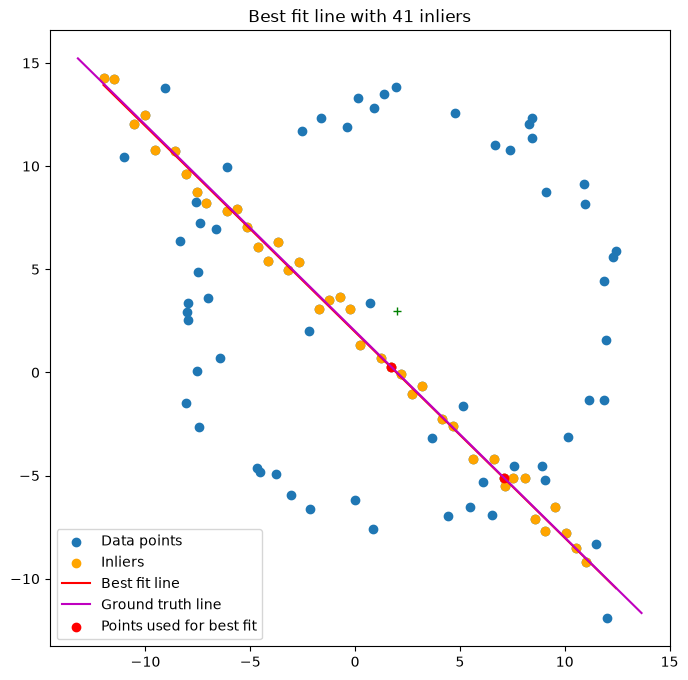

In [50]:
#Function to grenerate the line parameters
import math

def line_normal_form(x1, y1, x2, y2):
    dx, dy = x2 - x1, y2 - y1
    norm = math.hypot(dx, dy)
    if norm == 0:
        raise ValueError("The two points must be distinct.")
    a = dy / norm
    b = -dx / norm
    d = a * x1 + b * y1
    return a, b, d

def no_of_inliers(a, b, d, x, y, threshold):
    distances = np.abs(a * x + b * y - d)
    return np.sum(distances < threshold)
def is_inlier(a, b, d, x, y, threshold):
    distance = np.abs(a * x + b * y - d)
    return distance < threshold

    
rng = np.random.default_rng()

threshold = 0.75  # Distance threshold for inliers
no_of_iterations = 50
models=[]
X = np.vstack((X_circ, X_line))
x0, y0 = X[:, 0], X[:, 1]

for iterations in range(no_of_iterations):
    i, j = rng.choice(len(x0), size=2, replace=False)
    try:
        a, b, d = line_normal_form(x0[i], y0[i], x0[j], y0[j])
    except ValueError:
        continue
    inliers = no_of_inliers(a, b, d, x0, y0, threshold)
    models.append((a, b, d, inliers,x0[i],y0[i],x0[j],y0[j]))
best_model = max(models, key=lambda m: m[3])

a_best, b_best, d_best, inliers_best, x1,y1,x12,y12 = best_model
print(f"Best model: a={a_best:.4f}, b={b_best:.4f}, d={d_best:.4f}, inliers={inliers_best}")   
#drawing the best line

x_min, x_max = np.min(x0), np.max(x0)
y_min = (d_best - a_best * x_min) / b_best
y_max = (d_best - a_best * x_max) / b_best  
set_of_inliers = is_inlier(a_best, b_best, d_best, x0, y0, threshold)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(x0, y0, label='Data points')
ax.scatter(x0[set_of_inliers], y0[set_of_inliers], color='orange', label='Inliers')
ax.plot(x0_gt, y0_gt, '+', color='g')
x_50 = np.array([x_min, x_max])
y_50 = (d_best - a_best * x_50) / b_best
plt.plot(x_50, y_50, color='r', label='Best fit line')
y_ = -1* x_ + 2
plt.plot(x_, y_, color='m', label='Ground truth line')
plt.scatter([x1, x12], [y1, y12], color='red', label='Points used for best fit')
plt.legend()
plt.title(f'Best fit line with {inliers_best} inliers')
plt.show()

#### RANSAC Circle

Best circle: center=(2.06, 2.85), radius=10.05 with 47 inliers.


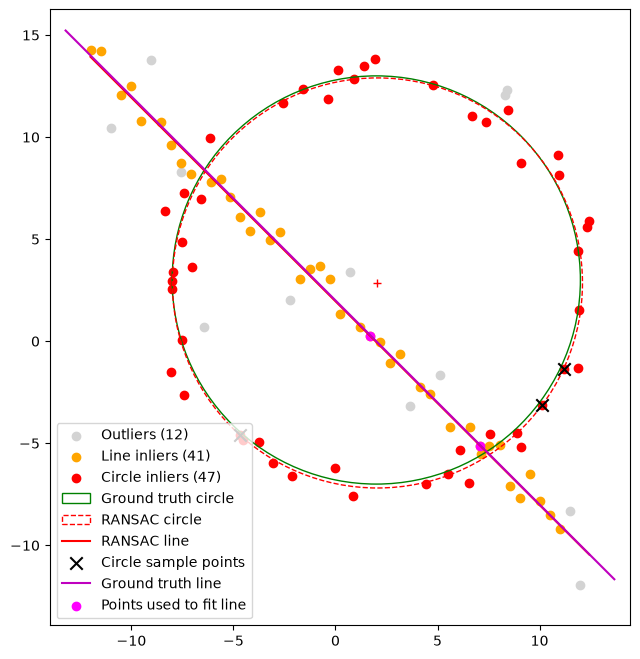

In [51]:
line_mask = np.abs(a_best*X[:,0]+b_best*X[:, 1]-d_best)<threshold
remaining_points = X[~line_mask]

def circlefit(x1, y1, x2, y2, x3, y3):
    A = np.array([[x1, y1, 1],
                  [x2, y2, 1],
                  [x3, y3, 1]])
    B = np.array([[-(x1**2 + y1**2)],
                  [-(x2**2 + y2**2)],
                  [-(x3**2 + y3**2)]])
    C = np.linalg.det(A)
    if C == 0:
        raise ValueError("The points are collinear.")
    D = np.linalg.det(np.hstack((B, A[:, 1:])))
    E = np.linalg.det(np.hstack((A[:, [0]], B, A[:, 2:])))
    F = np.linalg.det(np.hstack((A[:, :2], B)))
    
    x0 = -D / (2 * C)
    y0 = -E / (2 * C)
    r = np.sqrt((D**2 + E**2 - 4 * C * F) / (4 * C**2))
    
    return x0, y0, r
def error(x0, y0, r, x, y):
    return np.sqrt((x - x0)**2 + (y - y0)**2) - r

threshold_circ = 1  # Distance threshold for inliers
no_of_iterations = 100
best_circle, best_count = None, -1
rx, ry = remaining_points[:, 0], remaining_points[:, 1]
for _ in range(no_of_iterations):
    i, j, k = rng.choice(len(remaining_points), size=3, replace=False)
    try:
        x2, y2, r = circlefit(rx[i], ry[i], rx[j], ry[j], rx[k], ry[k])
    except ValueError:
        continue
    count = np.sum(np.abs(error(x2, y2, r, rx, ry)) <threshold_circ)
    if count > best_count:
        best_circle, best_count,coordinates = (x2, y2, r), count, (rx[i], ry[i], rx[j], ry[j], rx[k], ry[k])

x0_best, y0_best, r_best = best_circle
print(f"Best circle: center=({x0_best:.2f}, {y0_best:.2f}), radius={r_best:.2f} with {best_count} inliers.")

# line inliers: over all points in X
line_mask = np.abs(a_best * X[:, 0] + b_best * X[:, 1] - d_best) < threshold

# circle inliers: over the remaining points (the same set the circle RANSAC used)
circ_mask_rem = np.abs(error(x0_best, y0_best, r_best, rx, ry)) < threshold_circ
circ_inliers = remaining_points[circ_mask_rem]
line_inliers = X[line_mask]
outliers = remaining_points[~circ_mask_rem]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(*outliers.T,     c='lightgray',label=f'Outliers ({len(outliers)})')
ax.scatter(*line_inliers.T, c='orange',label=f'Line inliers ({len(line_inliers)})')
ax.scatter(*circ_inliers.T, c='red',label=f'Circle inliers ({len(circ_inliers)})')

ax.add_patch(plt.Circle((2, 3), 10, color='g', fill=False, label='Ground truth circle'))
ax.add_patch(plt.Circle((x0_best, y0_best), r_best, color='r', fill=False,
                        linestyle='--', label='RANSAC circle'))
ax.plot(x0_best, y0_best, 'r+')
plt.plot(x_50, y_50, color='r', label='RANSAC line')

# the 3 sample points that defined the best circle
cx, cy = np.array(coordinates[0::2]), np.array(coordinates[1::2])
ax.scatter(cx, cy, c='k', marker='x', s=80, label='Circle sample points')
y_ = -1* x_ + 2
plt.plot(x_, y_, color='m', label='Ground truth line')
plt.scatter([x1,x12], [y1,y12], color='magenta', label='Points used to fit line')
ax.set_xlim(X[:, 0].min() - 2, X[:, 0].max() + 2)
ax.set_ylim(X[:, 1].min() - 2, X[:, 1].max() + 2)
ax.set_aspect('equal')
ax.legend()
plt.show()



If we plot the circle  first, then  fitting the circle first works better here. The circle has less noise, so RANSAC finds it easily, and then the line is fitted on the points that are left.

### Question 3 - Computing Homography

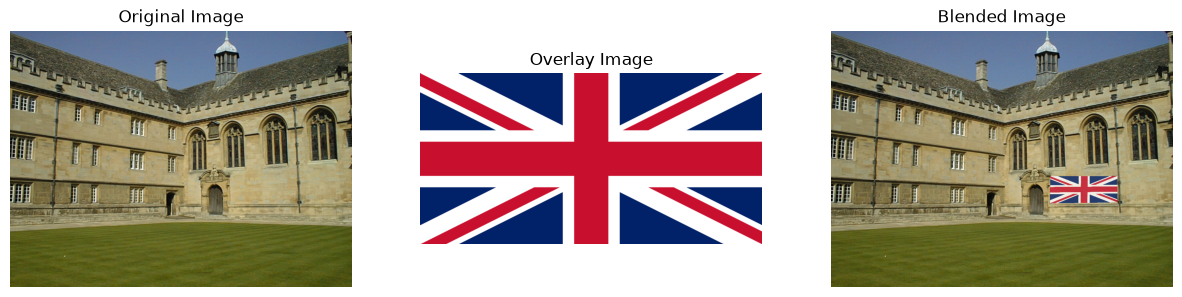

In [58]:
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np

image1 = cv.imread('wadham.jpg', cv.IMREAD_COLOR)
image2 = cv.imread("flag.png", cv.IMREAD_COLOR)

h,w= image2.shape[:2] #size of the second image
corners=[]
def click_event(event, x, y, flags, params):
    if event == cv.EVENT_LBUTTONDOWN and len(corners) < 4:
        corners.append((x, y))
image_display = image1.copy()
cv.imshow('image1', image_display)
cv.setMouseCallback('image1', click_event)  
cv.waitKey(0)
cv.destroyAllWindows()
H,_=cv.findHomography(np.array([[0,0],[w-1,0],[w-1,h-1],[0,h-1]]), np.array(corners))
im_out = cv.warpPerspective(image2, H, (image1.shape[1], image1.shape[0]))
mask = cv.warpPerspective(np.full((h, w), 255, np.uint8), H, (image1.shape[1], image1.shape[0]))
mask3 = (mask > 0)[..., None]

alpha = 0.8  # flag weight
blended = np.where(mask3,cv.addWeighted(image1, 1 - alpha, im_out, alpha, 0),image1.astype(np.uint8))

cv.imshow('Blended Image', blended)
cv.waitKey(0)
cv.destroyAllWindows()

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, im, t in zip(ax, [image1, image2, blended],['Original Image', 'Overlay Image', 'Blended Image']):
    a.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
    a.set_title(t)
    a.axis('off')
plt.show()

Here I have chosen, flat and well-defined surface since hommographu only holds for planes and avoid curves

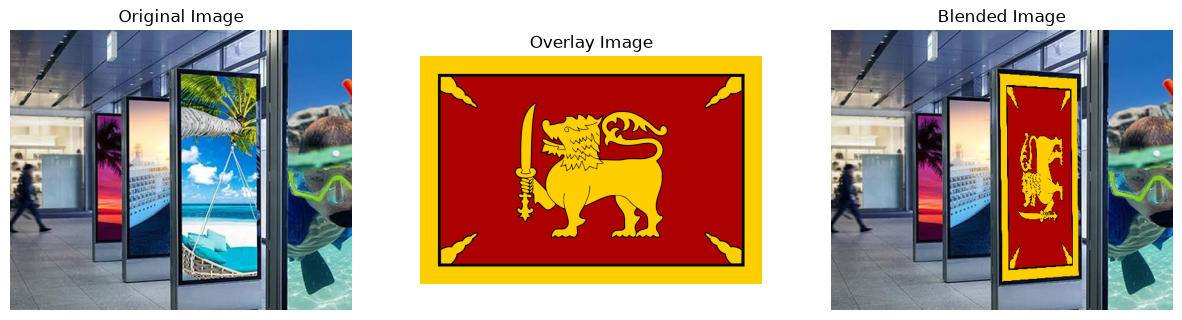

In [67]:
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np

image3 = cv.imread('tv.jpg', cv.IMREAD_COLOR)
image4 = cv.imread("sri lanka.png", cv.IMREAD_COLOR)

h,w= image4.shape[:2] #size of the second image
corners=[]
def click_event(event, x, y, flags, params):
    if event == cv.EVENT_LBUTTONDOWN and len(corners) < 4:
        corners.append((x, y))
image_display = image3 .copy()
cv.imshow('image3', image_display)
cv.setMouseCallback('image3', click_event)  
cv.waitKey(0)
cv.destroyAllWindows()
H,_=cv.findHomography(np.array([[0,0],[w-1,0],[w-1,h-1],[0,h-1]]), np.array(corners))
im_out = cv.warpPerspective(image4, H, (image3.shape[1], image3.shape[0]))
mask = cv.warpPerspective(np.full((h, w), 255, np.uint8), H, (image3.shape[1], image3.shape[0]))
mask3 = (mask > 0)[..., None]

alpha = 1  # flag weight
blended = np.where(mask3,cv.addWeighted(image3, 1 - alpha, im_out, alpha, 0),image3.astype(np.uint8))

cv.imshow('Blended Image', blended)
cv.waitKey(0)
cv.destroyAllWindows()

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, im, t in zip(ax, [image3, image4, blended],['Original Image', 'Overlay Image', 'Blended Image']):
    a.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
    a.set_title(t)
    a.axis('off')
plt.show()

In this picture, the corners of a TV screen is selected to compute the homography

### Question 4 - SIFT

Template keypoints: 14271
Image keypoints: 12312
Good matches: 4607, RANSAC inliers: 3951


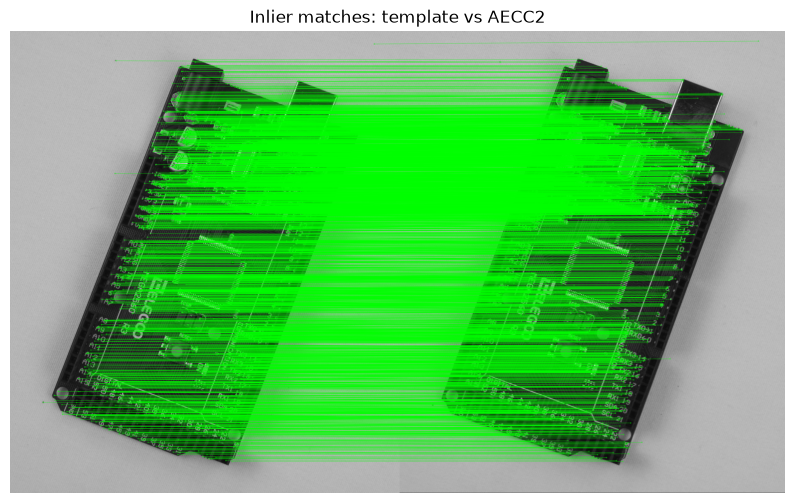

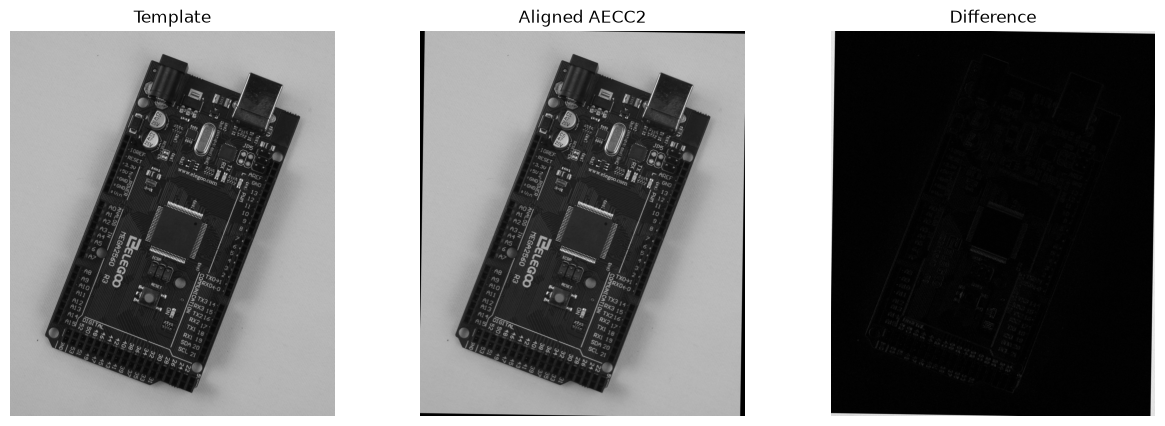

Image keypoints: 2413
Good matches: 397, RANSAC inliers: 82


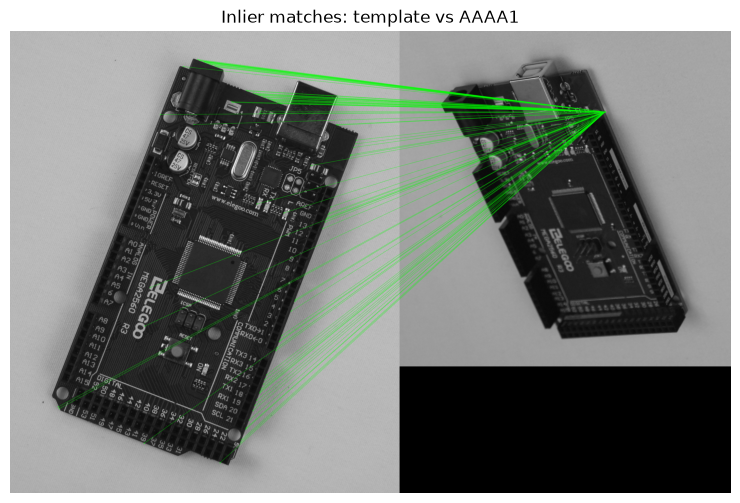

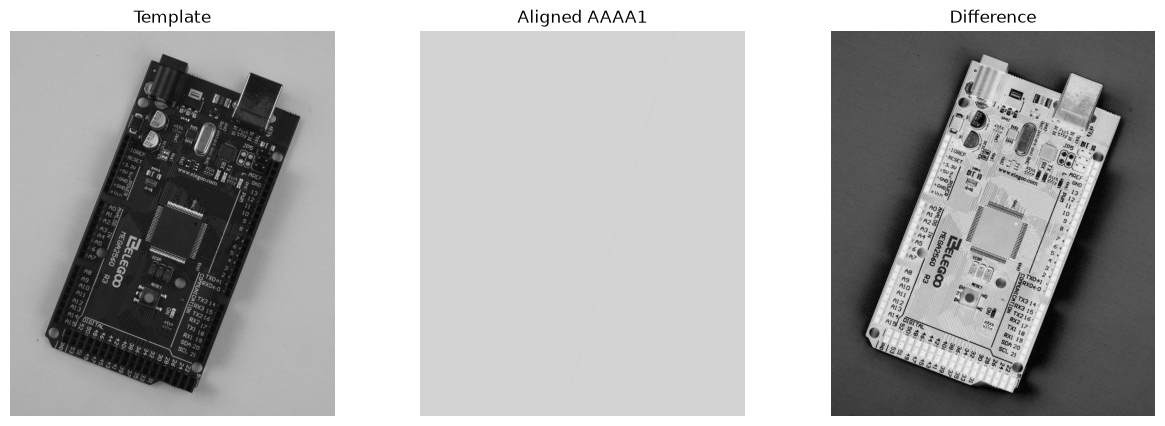

Image keypoints: 8488
Good matches: 656, RANSAC inliers: 226


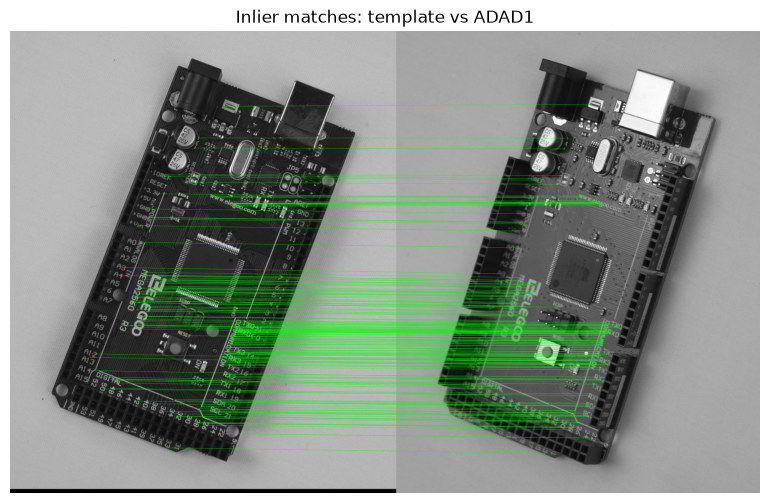

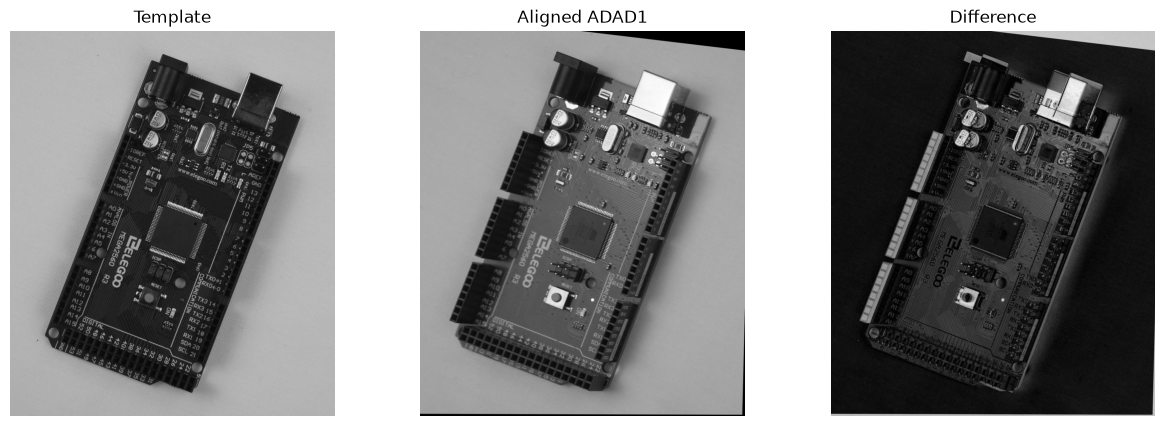

In [ ]:
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np

template = cv.imread('pcbs/AECC1.jpg', cv.IMREAD_GRAYSCALE)
im1 = cv.imread('pcbs/AECC2.jpg', cv.IMREAD_GRAYSCALE)
im2 = cv.imread('pcbs/AAAA1.jpg', cv.IMREAD_GRAYSCALE)
im3 = cv.imread('pcbs/ADAD1.jpg', cv.IMREAD_GRAYSCALE)

for name, im in (('AECC1', template), ('AECC2', im1), ('AAAA1', im2), ('ADAD1', im3)):
    if im is None:
        raise FileNotFoundError(f'Could not load {name}; check the path')

sift = cv.SIFT_create()
bf = cv.BFMatcher(cv.NORM_L2)
kp1, des1 = sift.detectAndCompute(template, None)
print(f'Template keypoints: {len(kp1)}')


def align(template, img, kp_t, des_t):
    kp, des = sift.detectAndCompute(img, None)
    print(f'Image keypoints: {len(kp)}')
    knn = bf.knnMatch(des_t, des, k=2)
    good = [m for m, n in knn if m.distance < 0.75 * n.distance]

    src = np.float32([kp_t[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([kp[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, mask = cv.findHomography(src, dst, cv.RANSAC, 5.0)
    print(f'Good matches: {len(good)}, RANSAC inliers: {int(mask.sum())}')
    vis = cv.drawMatches(template, kp_t, img, kp, good, None,
                         matchColor=(0, 255, 0), singlePointColor=None,
                         matchesMask=mask.ravel().tolist(),
                         flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)  
    h, w = template.shape[:2]
    
    aligned = cv.warpPerspective(img, H, (w, h),
                                 flags=cv.WARP_INVERSE_MAP | cv.INTER_LINEAR)
    diff = cv.absdiff(template, aligned)
    return vis, aligned, diff


for name, img in (('AECC2', im1), ('AAAA1', im2), ('ADAD1', im3)):
    vis, aligned, diff = align(template, img, kp1, des1)

    # Matches
    plt.figure(figsize=(12, 6))
    plt.imshow(vis)
    plt.title(f'Inlier matches: template vs {name}')
    plt.axis('off')
    plt.show()


    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    for a, im, title in zip(ax, [template, aligned, diff],
                            ['Template', f'Aligned {name}', 'Difference']):
        a.imshow(im, cmap='gray')
        a.set_title(title)
        a.axis('off')
    plt.show()